<a href="https://colab.research.google.com/github/sushantv2v/LLM-TRANSFORMER/blob/collab-branch/Pytorch_basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

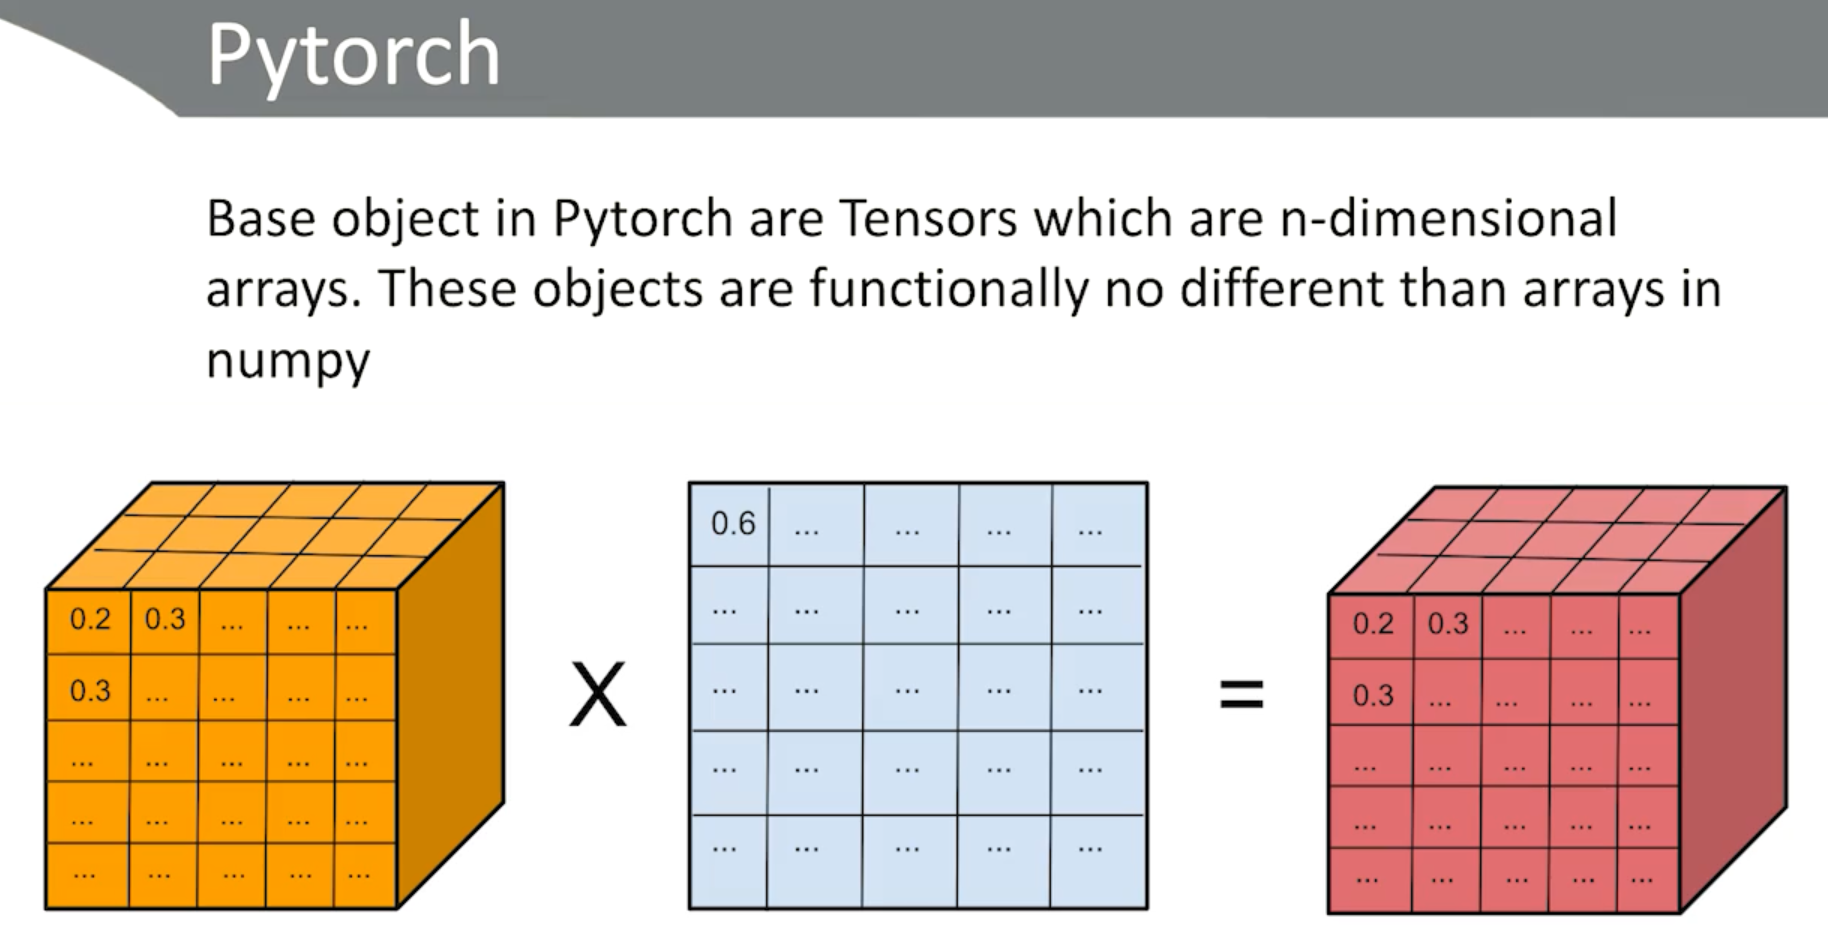

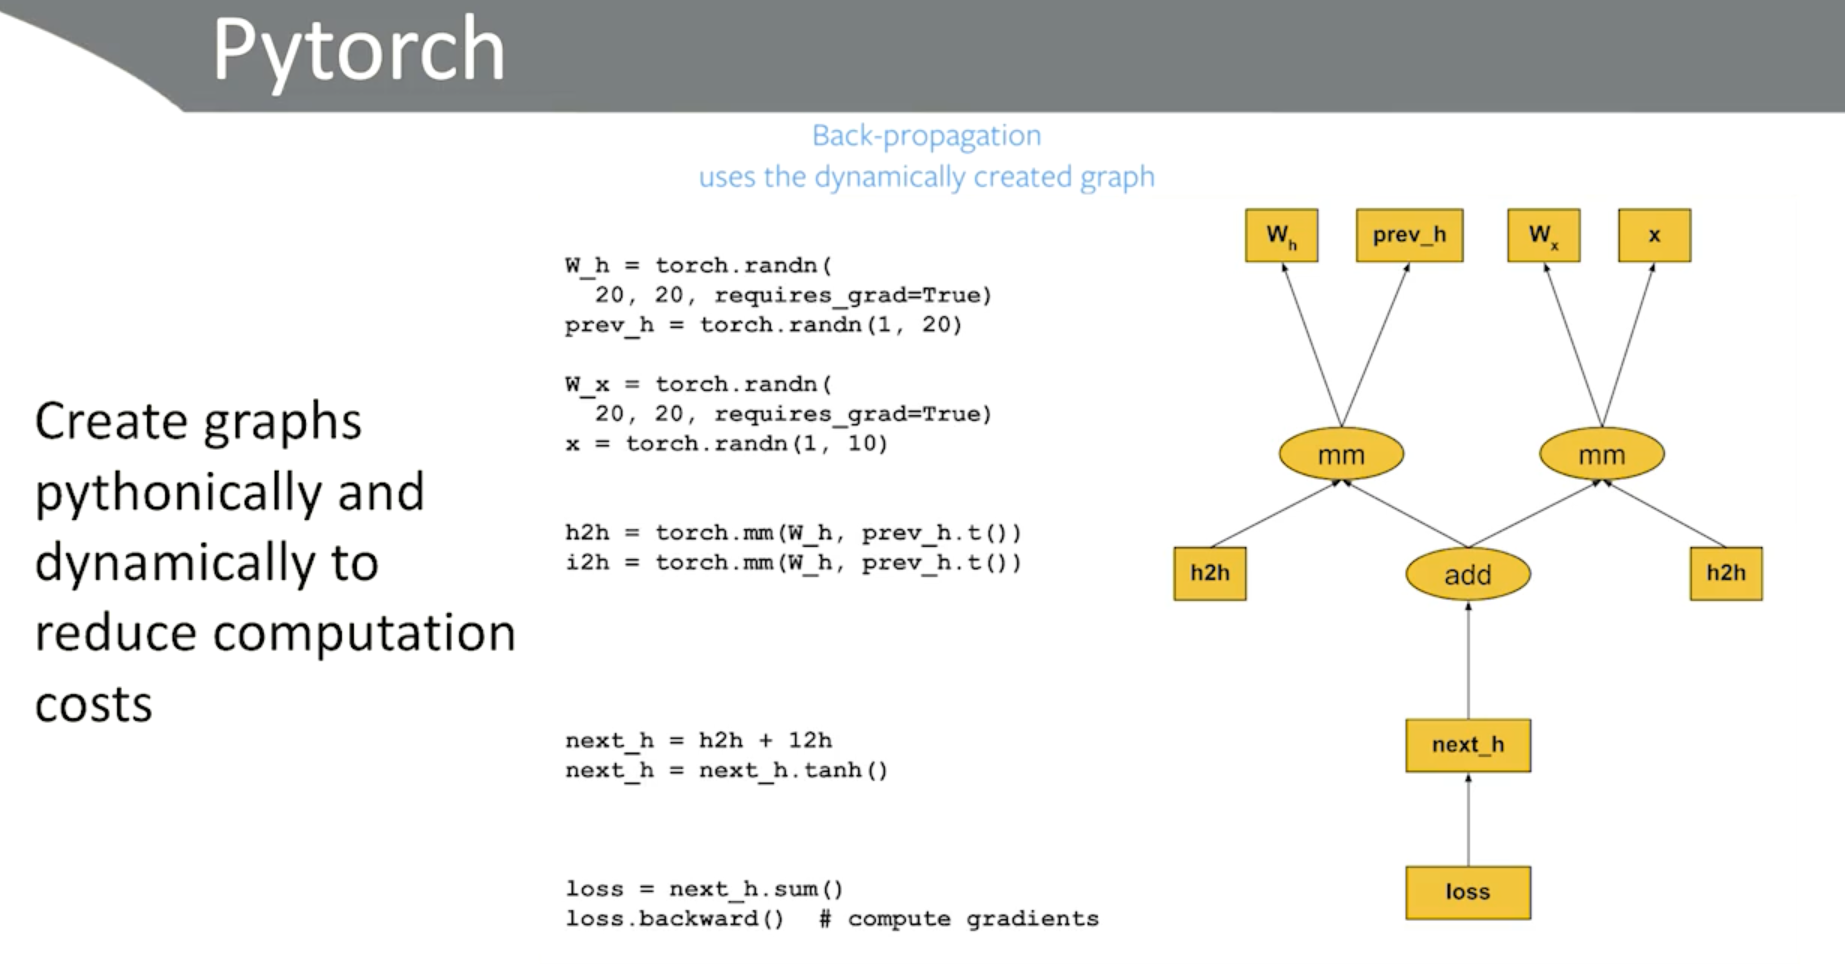

Let's see some code

In [2]:
import torch

In [3]:
one_d_tensor = torch.LongTensor([0])

print(f'Shape of {one_d_tensor} is {one_d_tensor.shape} and dimension is {one_d_tensor.dim()}' )

Shape of tensor([0]) is torch.Size([1]) and dimension is 1


In [4]:
one_d_tensor = torch.LongTensor([1,2,3])

print(f'Shape of {one_d_tensor} is {one_d_tensor.shape} and dimension is {one_d_tensor.dim()}' )

Shape of tensor([1, 2, 3]) is torch.Size([3]) and dimension is 1


In [5]:
one_d_tensor = torch.LongTensor([[1,2,3],[3,4,5]])

print(f'Shape of {one_d_tensor} is {one_d_tensor.shape} and dimension is {one_d_tensor.dim()}' )

Shape of tensor([[1, 2, 3],
        [3, 4, 5]]) is torch.Size([2, 3]) and dimension is 2


In [6]:
one_d_tensor = torch.LongTensor([[1,2,3],[3,4,5],[4,5,6]])

print(f'Shape of {one_d_tensor} is {one_d_tensor.shape} and dimension is {one_d_tensor.dim()}' )

Shape of tensor([[1, 2, 3],
        [3, 4, 5],
        [4, 5, 6]]) is torch.Size([3, 3]) and dimension is 2


In [7]:
one_d_tensor = torch.LongTensor([[1,2,3],[3,4,5],[4,5,6]])

print(f'Shape of {one_d_tensor} is {one_d_tensor.shape} and dimension is {one_d_tensor.dim()}' )

Shape of tensor([[1, 2, 3],
        [3, 4, 5],
        [4, 5, 6]]) is torch.Size([3, 3]) and dimension is 2


In [8]:
one_d_tensor = torch.LongTensor([1,2,3])

print(f'Shape of {one_d_tensor} is {one_d_tensor.shape} and dimension is {one_d_tensor.dim()}' )


#convert 1-dim tensor to 2-dim tensor by forcing a dimension in the front
# this is useful when we want to force a 'batch' dimension if we want to predict a single example

two_d_tensor = one_d_tensor.unsqueeze(0)

print(f'Shape of {two_d_tensor} is {two_d_tensor.shape} and dimension is {two_d_tensor.dim()}' )

Shape of tensor([1, 2, 3]) is torch.Size([3]) and dimension is 1
Shape of tensor([[1, 2, 3]]) is torch.Size([1, 3]) and dimension is 2


In [12]:
#converting pytorch to numpy

two_d_tensor.numpy()

array([[1, 2, 3]])

# **Fine-tuning transformers with PyTorch**

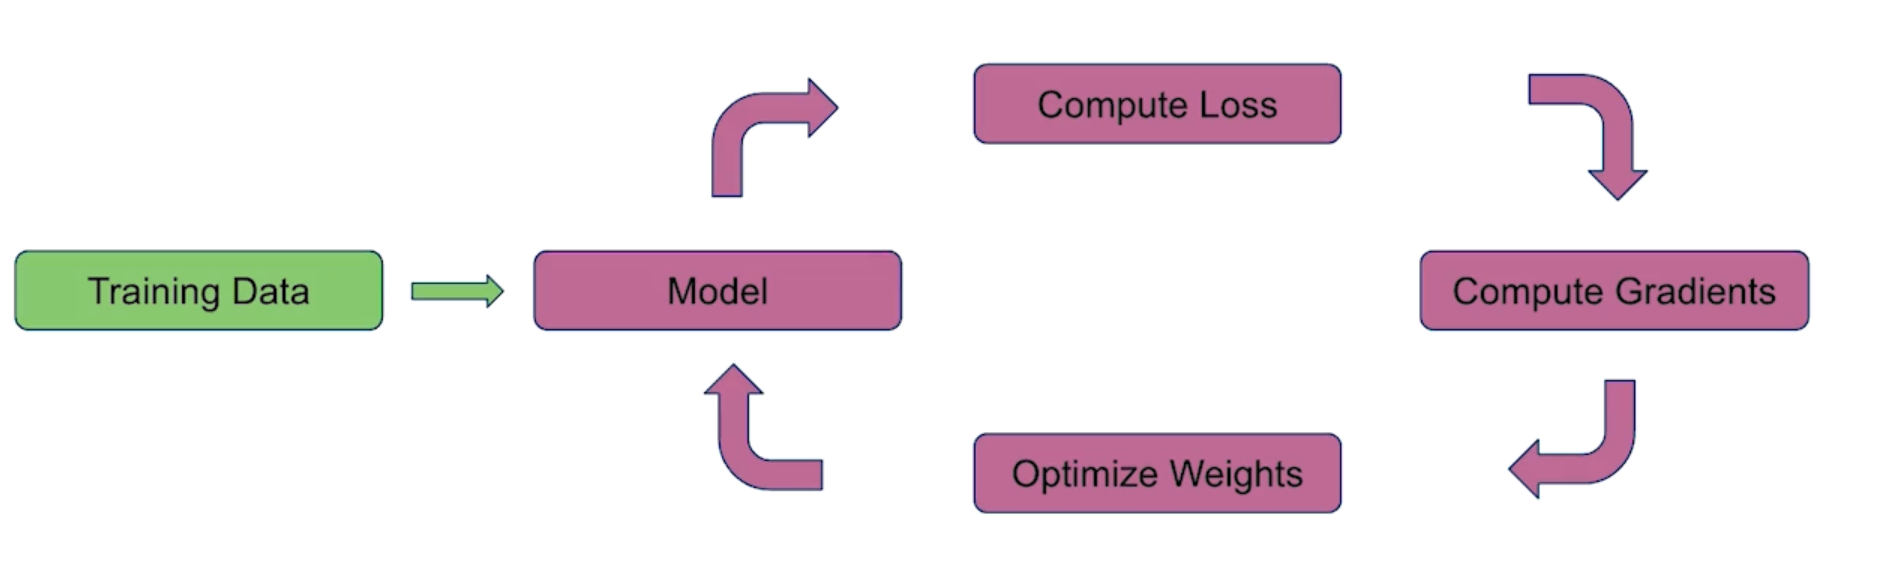

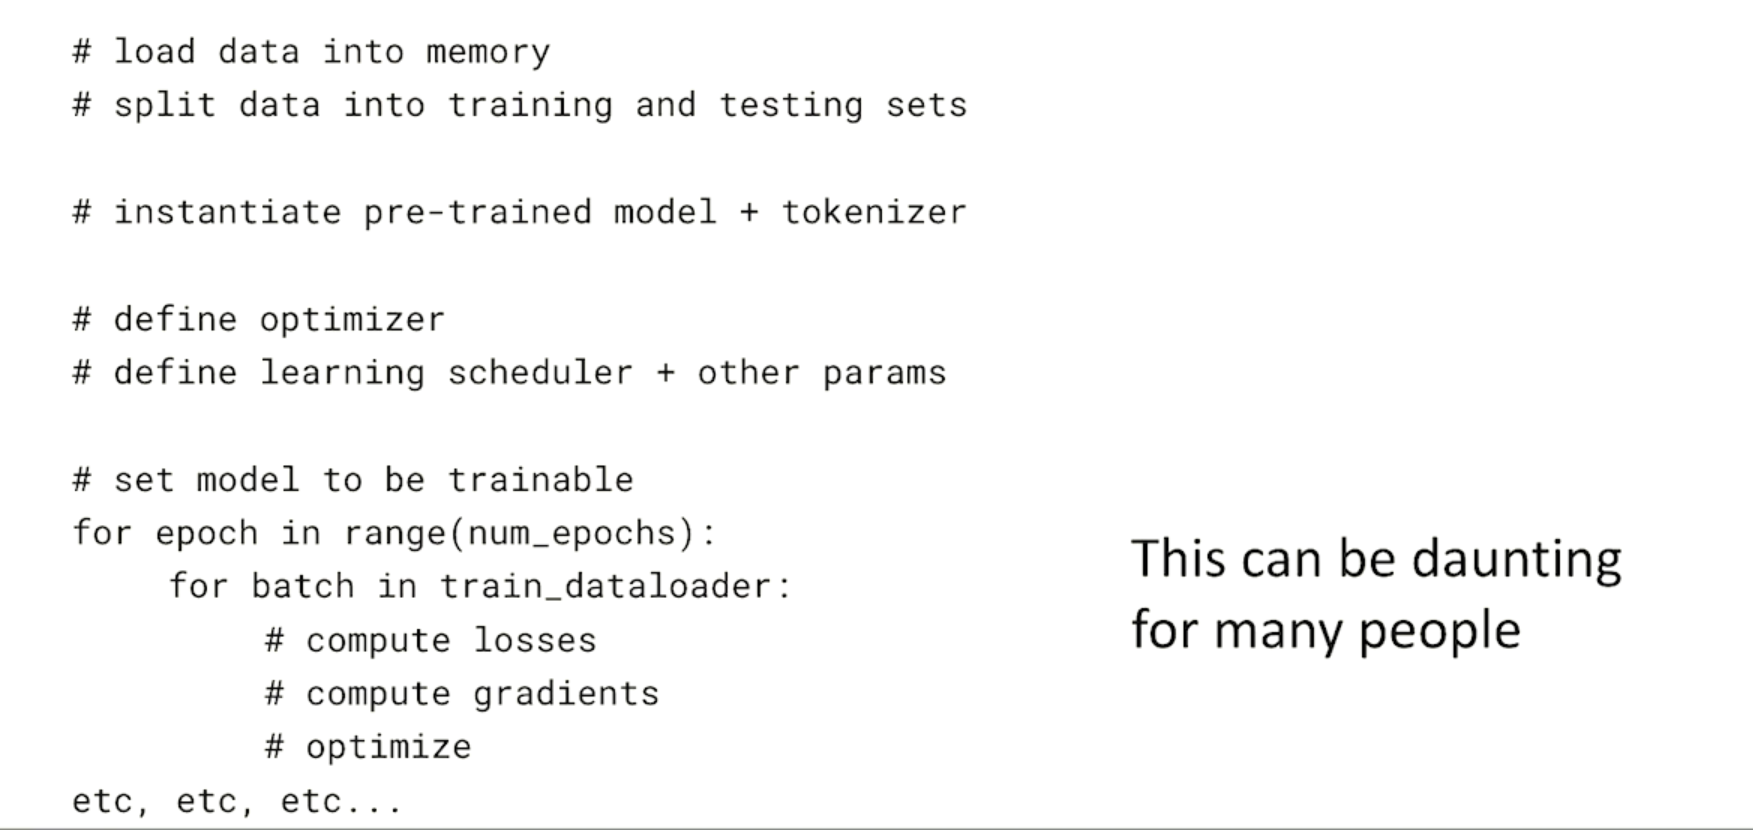

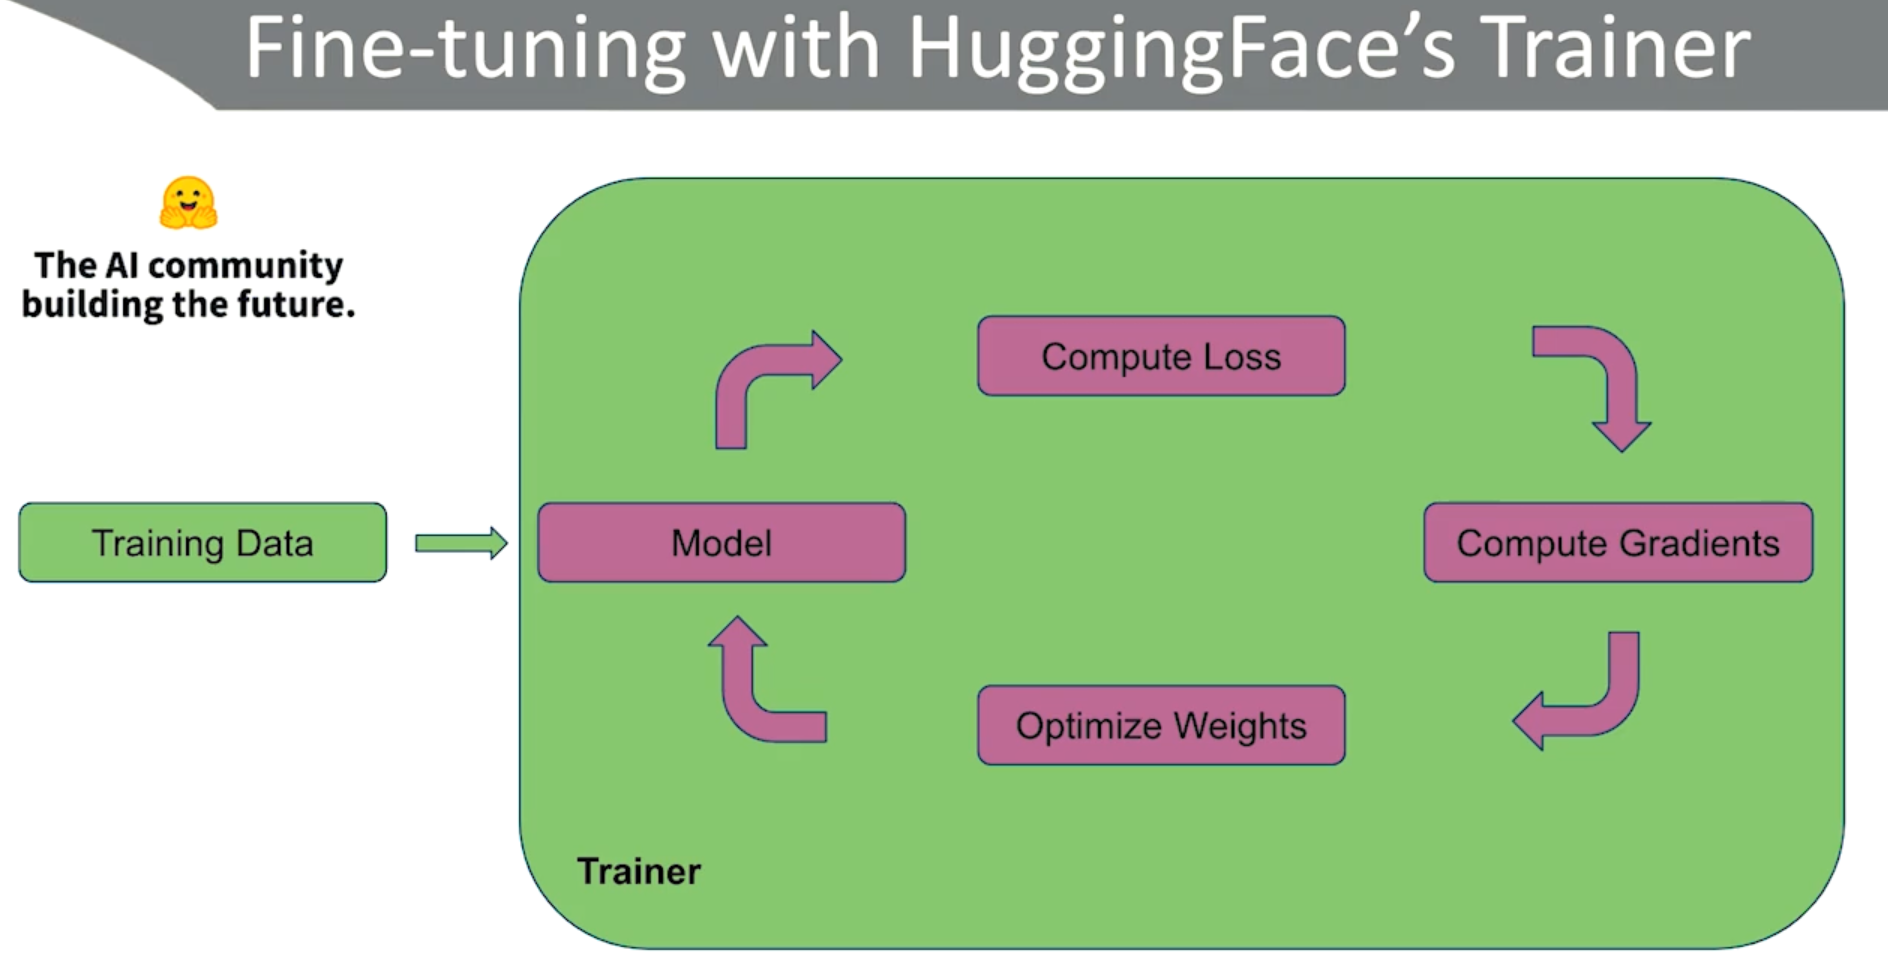

Keep object in HuggingFace's Trainer module

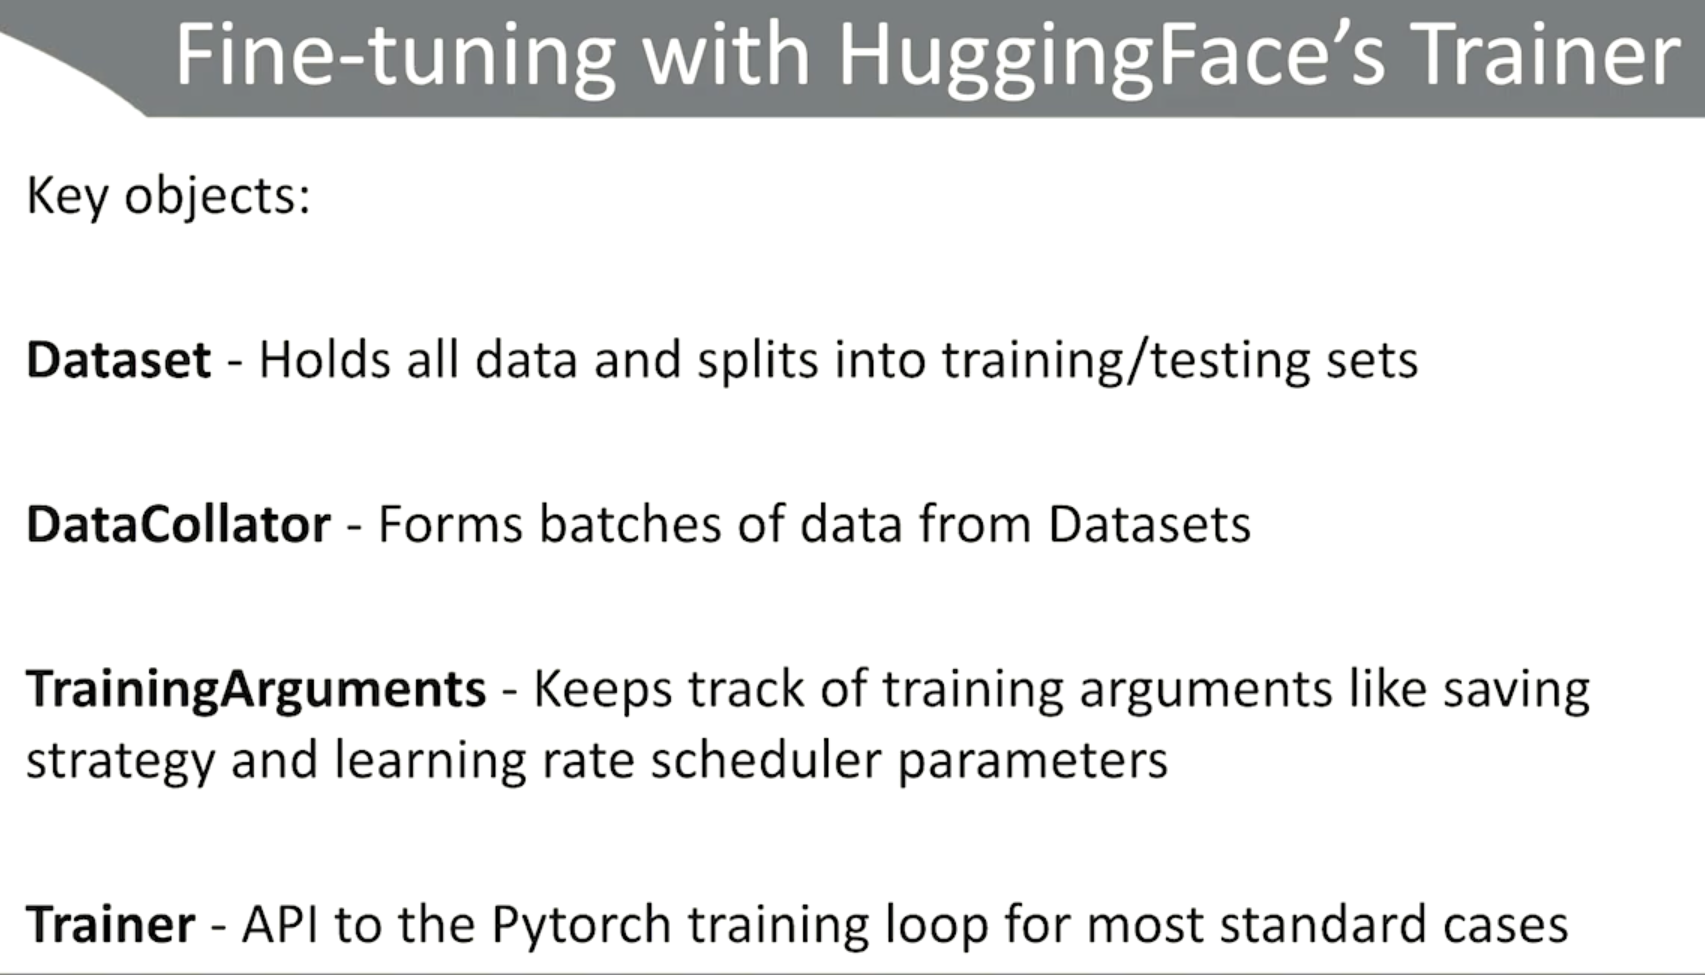

with Hugging Face's trainer API. The first is a dataset object. This is pretty self-explanatory. It holds all of the data and it also has some built-in methods to split into training and test sets. And it's basically the container that holds all of our data.
Then we have a data collator. A data collator's main job is to form batches of data from a dataset. So a data collator on its own is pretty useless. It works in conjunction with a dataset to provide batches of data for our models.
So our data set is all of our data. Our collator takes batches of data and hands it over to our model. Our training arguments are an object that keeps track of training arguments, as the name suggests. Like when to save our model, should we save it every epoch, should we save it every how many batches,
what's our learning rate, so we have a learning rate scheduler? All of those aspects of deep learning training exist in the training arguments.

On top of all of this is the trainer object. This is our main API into the PyTorch training loop for pretty much all standard cases. It is a wrapper on top of that that four loop that we saw earlier going through the epoch and the batches it does all of that for us. The trainer takes in a dataset, a data collator, and training arguments, and then we have simple access to methods like evaluate, train, predict. Those simple methods that we would have to implement manually in native PyTorch.

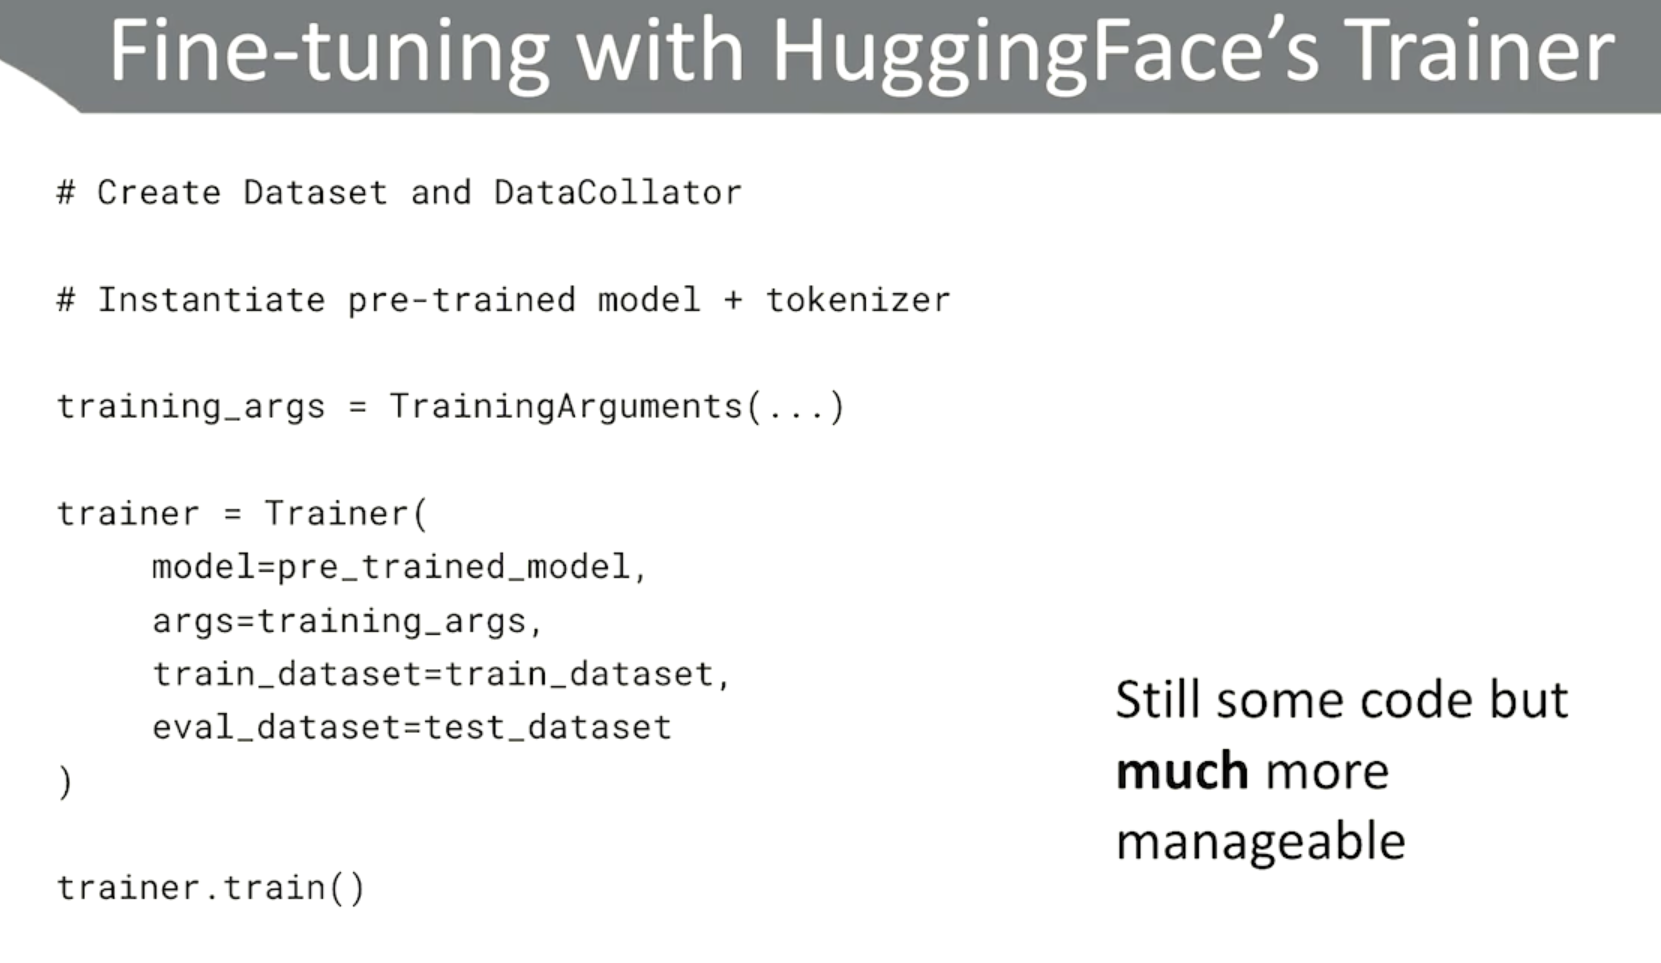

# **BERT's Architecture**

In [18]:
from transformers import BertTokenizer, BertModel
import torch
from sklearn.metrics.pairwise import cosine_similarity

In [19]:
#let's load the vanilla bert-base model.
model = BertModel.from_pretrained('bert-base-uncased')

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

In [20]:
from os import name
named_params = list(model.named_parameters())

print('The Bert model has {:} different named parameters. \n'.format(len(named_params)))

print('==== Embedding Layer ====\n')

for p in named_params[0:5]:
  print("{:<55} {:12}".format(p[0],str(tuple(p[1].size()))) )

print('==== First Encoder ====\n')
for p in named_params[5:21]:
  print("{:<55} {:12}".format(p[0],str(tuple(p[1].size()))) )

print('==== Output Layer ====\n')
for p in named_params[-2:]:
  print("{:<55} {:12}".format(p[0],str(tuple(p[1].size()))) )



The Bert model has 199 different named parameters. 

==== Embedding Layer ====

embeddings.word_embeddings.weight                       (30522, 768)
embeddings.position_embeddings.weight                   (512, 768)  
embeddings.token_type_embeddings.weight                 (2, 768)    
embeddings.LayerNorm.weight                             (768,)      
embeddings.LayerNorm.bias                               (768,)      
==== First Encoder ====

encoder.layer.0.attention.self.query.weight             (768, 768)  
encoder.layer.0.attention.self.query.bias               (768,)      
encoder.layer.0.attention.self.key.weight               (768, 768)  
encoder.layer.0.attention.self.key.bias                 (768,)      
encoder.layer.0.attention.self.value.weight             (768, 768)  
encoder.layer.0.attention.self.value.bias               (768,)      
encoder.layer.0.attention.output.dense.weight           (768, 768)  
encoder.layer.0.attention.output.dense.bias             (768,)     

The pooler is a separate linear and tanh activated layer that acts on the [CLS] token's representation
This pooled output is often used as a representation for the entire sentence.

In [21]:
#let's load the tokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

In [22]:
tokenizer.encode('sushant loves a mango') #tokenize a simple sequence

[101, 10514, 9688, 2102, 7459, 1037, 24792, 102]

In [23]:
# run tokens through the model
#1 Turn tokens_with_unknown_words into a tensor (will be size (8,))
#2 Unsqueeze a first dimension to simulate batches. Resulting shape is (1, 8)

response = model(torch.tensor(tokenizer.encode( 'sushant loves a mango')).unsqueeze(0))

In [24]:
#embedding for each token, the first one being the [CLS] token

response.last_hidden_state

tensor([[[-0.3434, -0.0275, -0.1983,  ..., -0.2135,  0.6350,  0.3784],
         [ 0.3309, -0.7764, -0.1649,  ...,  0.0540,  0.9401,  0.1934],
         [ 0.9085, -0.9902,  0.0443,  ..., -0.4947,  0.4142, -1.3087],
         ...,
         [-0.2031,  0.0302, -0.1233,  ..., -0.2188,  0.2499,  0.1299],
         [ 0.0777,  0.2280, -0.7787,  ...,  0.1332, -0.0592, -0.5064],
         [ 0.6178, -0.0158, -0.1776,  ..., -0.0148, -0.2458, -0.3793]]],
       grad_fn=<NativeLayerNormBackward0>)

In [25]:
#this layer is trained on top of the embedding of the [CLS] token
response.pooler_output.shape

torch.Size([1, 768])

In [26]:
model.pooler

BertPooler(
  (dense): Linear(in_features=768, out_features=768, bias=True)
  (activation): Tanh()
)

In [27]:
#Grab the final encoder's representation of the CLS token

CLS_embedding = response.last_hidden_state[:,0,:].unsqueeze(0)

CLS_embedding.shape

torch.Size([1, 1, 768])

	•	[:, 0, :] is using PyTorch tensor slicing:
	•	: → all batches
	•	0 → the first token of the sequence (often [CLS] in models like BERT)
	•	: → all hidden dimensions


In [28]:
model.pooler(CLS_embedding).shape

torch.Size([1, 768])

this tensor is the vector representation of the entire sequence at large.

In [29]:
# Running the embedding for CLS through the pooler gives the same output as the pooler_output
(model.pooler(CLS_embedding) == response.pooler_output).all()

tensor(True)

In [30]:
total_params = 0

for p in model.parameters():
  if len(p.shape) ==2:
    total_params += p.shape[0] * p.shape[1]

print(f'Total Parameters: {total_params : ,}')    #this is where 110M parameters come from

Total Parameters:  109,360,128


In [31]:
30522*768 #out of 110M this 30522 ( vocab) * (768)dim , 23m is from contextless word embedding

23440896

# **Wordpiece Tokenization**

In [32]:
from transformers import BertModel, BertTokenizer
import torch
from sklearn.metrics.pairwise import cosine_similarity

In [33]:
#load the bert-base uncased tokenizer.

#when we talk about uncased means whenever we pass a sentence or sequence through the tokenzier, we will be performing a pre-processing step of lower casing it
#and removing the accents.


tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

print(f'Length of BERT base vocabulary: {len(tokenizer.vocab)}')




Length of BERT base vocabulary: 30522


In [34]:
text = "A simple sentence!"


tokens = tokenizer.encode(text) #get token ids per BERT-base's vocabulary

print(tokens)

[101, 1037, 3722, 6251, 999, 102]


In [35]:
#decode will re-construct the sentence with the added [CLS] and [SEP] token

tokenizer.decode(tokens)

'[CLS] a simple sentence! [SEP]'

In [36]:
text = 'My friend told me about this class and I love it so far! She was right.'

tokens = tokenizer.encode(text)

print(tokens)

[101, 2026, 2767, 2409, 2033, 2055, 2023, 2465, 1998, 1045, 2293, 2009, 2061, 2521, 999, 2016, 2001, 2157, 1012, 102]


In [37]:
print(f'text: {text}. Num tokens : {len(tokens)}')
for t in tokens:

  print(f'Token: {t} \t subword: {tokenizer.decode([t])}')

text: My friend told me about this class and I love it so far! She was right.. Num tokens : 20
Token: 101 	 subword: [CLS]
Token: 2026 	 subword: my
Token: 2767 	 subword: friend
Token: 2409 	 subword: told
Token: 2033 	 subword: me
Token: 2055 	 subword: about
Token: 2023 	 subword: this
Token: 2465 	 subword: class
Token: 1998 	 subword: and
Token: 1045 	 subword: i
Token: 2293 	 subword: love
Token: 2009 	 subword: it
Token: 2061 	 subword: so
Token: 2521 	 subword: far
Token: 999 	 subword: !
Token: 2016 	 subword: she
Token: 2001 	 subword: was
Token: 2157 	 subword: right
Token: 1012 	 subword: .
Token: 102 	 subword: [SEP]


In [38]:
'sushant' in tokenizer.vocab

False

In [39]:
text_with_unknown_words = 'Sushant loves a mangoes'
token_with_unkown_words = tokenizer.encode(text_with_unknown_words)



for t in token_with_unkown_words:

  print(f'Token: {t} \t subword: {tokenizer.decode([t])}')

Token: 101 	 subword: [CLS]
Token: 10514 	 subword: su
Token: 9688 	 subword: ##shan
Token: 2102 	 subword: ##t
Token: 7459 	 subword: loves
Token: 1037 	 subword: a
Token: 24792 	 subword: mango
Token: 2229 	 subword: ##es
Token: 102 	 subword: [SEP]


Now, so far, we've been using just encode,
which gives us a list of our token IDs. Now, we'll mostly be using encode_plus. The encode_plus is going to give us multiple things.

tokenizer.encode_plus(...) Outputs:

Here’s what it returns (typically in a dictionary):

	1.	input_ids:

	•	These are the token IDs corresponding to the tokens from your input text.
	•	Example: "Hello world" → [101, 7592, 2088, 102] (IDs may vary based on tokenizer).

	2.	attention_mask:

	•	A list of 1s and 0s.
	•	1: Include this token in attention computations.
	•	0: Mask this token; ignore it during attention.
	•	Use-case: Mostly used during padding to ensure the model doesn’t learn from padded (non-informative) parts of the input.

	3.	token_type_ids:
  
	•	Used only in sentence-pair tasks, like question-answering or next sentence prediction.
	•	Distinguishes between sentence A and sentence B in a combined input like [CLS] A [SEP] B [SEP].
	•	Tokens from Sentence A get 0, Sentence B get 1.

⸻


When is this extra information useful?

	•	Attention Mask: Crucial when you’re using padded sequences in batch processing. Models like BERT require this to avoid learning from [PAD] tokens.

	•	Token Type IDs: Needed for tasks like Natural Language Inference (NLI), QA, or anything with sentence pairs.

⸻


In [40]:
text = 'My friend told me about this class and I love it so far! She was right.'

tokens = tokenizer.encode_plus(text)

print(tokens)

{'input_ids': [101, 2026, 2767, 2409, 2033, 2055, 2023, 2465, 1998, 1045, 2293, 2009, 2061, 2521, 999, 2016, 2001, 2157, 1012, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [41]:
#calling the tokenizer direclty doest the same thing as encode_plus

tokenizer(text)

{'input_ids': [101, 2026, 2767, 2409, 2033, 2055, 2023, 2465, 1998, 1045, 2293, 2009, 2061, 2521, 999, 2016, 2001, 2157, 1012, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

# Let's check if we are getting context full represntation of the sentences or not?

In [42]:
#python is the 6th token (don't forget the [CLS] token!)

python_pet = tokenizer.encode('I love my pet python')

python_pet

[101, 1045, 2293, 2026, 9004, 18750, 102]

In [43]:
#python is the 6th token (don't forget the [CLS] token!)

python_language = tokenizer.encode('I love coding in python')

python_language

[101, 1045, 2293, 16861, 1999, 18750, 102]

In [49]:
#contextful embedding of python in 'I love my pet python'

python_pet_embedding = model(torch.tensor(python_pet).unsqueeze(0))
python_pet_embedding = python_pet_embedding[0][:,5,:].detach().numpy()

In [51]:
#contextful embedding of python in 'I love coding in python'

python_language_embedding = model(torch.tensor(python_language).unsqueeze(0))
python_language_embedding = python_language_embedding[0][:,5,:].detach().numpy()

In [52]:

#contextful embedding of 'snake' in 'snake'

snake_alone_embedding = model(torch.tensor(tokenizer.encode('snake')).unsqueeze(0))
snake_alone_embedding = snake_alone_embedding[0][:,1,:].detach().numpy()

In [53]:

#contextful embedding of 'programming' in 'programming'

programming_alone_embedding = model(torch.tensor(tokenizer.encode('programming')).unsqueeze(0))
programming_alone_embedding = programming_alone_embedding[0][:,1,:].detach().numpy()

In [57]:
python_language_embedding.shape

(1, 768)

In [54]:
cosine_similarity(python_language_embedding,snake_alone_embedding)

array([[0.5843479]], dtype=float32)

In [55]:
cosine_similarity(python_pet_embedding,snake_alone_embedding)

array([[0.6928656]], dtype=float32)

In [56]:
cosine_similarity(python_language_embedding,programming_alone_embedding)

array([[0.5614742]], dtype=float32)

In [58]:
cosine_similarity(python_pet_embedding,programming_alone_embedding)

array([[0.4986436]], dtype=float32)